In [1]:
import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset and Preprocessing
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.base import BaseEstimator, RegressorMixin

# Models
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from catboost import CatBoostRegressor

In [2]:
#Importing the template
data_path = "world_happiness_report.csv"
df = pd.read_csv(data_path)

In [3]:
#Information about null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1231 entries, 0 to 1230
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     1231 non-null   int64  
 1   Country                        617 non-null    object 
 2   Region                         315 non-null    object 
 3   Happiness Rank                 315 non-null    float64
 4   Happiness Score                315 non-null    float64
 5   Standard Error                 158 non-null    float64
 6   Economy (GDP per Capita)       315 non-null    float64
 7   Family                         470 non-null    float64
 8   Health (Life Expectancy)       315 non-null    float64
 9   Freedom                        470 non-null    float64
 10  Trust (Government Corruption)  315 non-null    float64
 11  Generosity                     1084 non-null   float64
 12  Dystopia Residual              315 non-null    f

**Data Analysis**
An initial analysis of the data reveals an unnamed column. Since we do not know what it refers to, we need to analyze its contents to determine whether to remove it. Since there are many rows with null values, we will assess the column’s usefulness before deciding how to use it. As for rows with null happiness score values, considering that this column will be used by the ML algorithm, we will replace as many null values as possible.

In [4]:
print(df["Unnamed: 0"])

0          0
1          1
2          2
3          3
4          4
        ... 
1226    1226
1227    1227
1228    1228
1229    1229
1230    1230
Name: Unnamed: 0, Length: 1231, dtype: int64


In [5]:
#The “unnamed” column contains the column count and can be deleted
#Furthermore, region and happiness rank are irrelevant to the analysis
#standard error might be useful, but it has too many null values
df = df.drop(columns=["Unnamed: 0", "Region", "Happiness Rank", "Standard Error"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1231 entries, 0 to 1230
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        617 non-null    object 
 1   Happiness Score                315 non-null    float64
 2   Economy (GDP per Capita)       315 non-null    float64
 3   Family                         470 non-null    float64
 4   Health (Life Expectancy)       315 non-null    float64
 5   Freedom                        470 non-null    float64
 6   Trust (Government Corruption)  315 non-null    float64
 7   Generosity                     1084 non-null   float64
 8   Dystopia Residual              315 non-null    float64
 9   year                           1231 non-null   int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 96.3+ KB


In [6]:
#Calculating the happiness score by imputing missing values using the mean and variance to ensure a range of values

indici_null = df[df['Happiness Score'].isna()].index

for i, idx in enumerate(indici_null):
    mean = df['Happiness Score'].mean()
    median = df['Happiness Score'].median()    
    if i % 2 == 0:  
        df.at[idx, 'Happiness Score'] = mean
    else:             
        df.at[idx, 'Happiness Score'] = median
        
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1231 entries, 0 to 1230
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        617 non-null    object 
 1   Happiness Score                1231 non-null   float64
 2   Economy (GDP per Capita)       315 non-null    float64
 3   Family                         470 non-null    float64
 4   Health (Life Expectancy)       315 non-null    float64
 5   Freedom                        470 non-null    float64
 6   Trust (Government Corruption)  315 non-null    float64
 7   Generosity                     1084 non-null   float64
 8   Dystopia Residual              315 non-null    float64
 9   year                           1231 non-null   int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 96.3+ KB


In [7]:
#using the same method as the happiness score for the other zero values
index_null = df[df['Economy (GDP per Capita)'].isna()].index

for i, idx in enumerate(index_null):
    mean = df['Economy (GDP per Capita)'].mean()
    median = df['Economy (GDP per Capita)'].median()    
    if i % 2 == 0:  
        df.at[idx, 'Economy (GDP per Capita)'] = mean
    else:             
        df.at[idx, 'Economy (GDP per Capita)'] = median    
        
index_null = df[df['Family'].isna()].index

for i, idx in enumerate(index_null):
    mean = df['Family'].mean()
    median = df['Family'].median()    
    if i % 2 == 0:  
        df.at[idx, 'Family'] = mean
    else:             
        df.at[idx, 'Family'] = median     

index_null = df[df['Health (Life Expectancy)'].isna()].index

for i, idx in enumerate(index_null):
    mean = df['Health (Life Expectancy)'].mean()
    median = df['Health (Life Expectancy)'].median()    
    if i % 2 == 0:  
        df.at[idx, 'Health (Life Expectancy)'] = mean
    else:             
        df.at[idx, 'Health (Life Expectancy)'] = median  
        
index_null = df[df['Freedom'].isna()].index

for i, idx in enumerate(index_null):
    mean = df['Freedom'].mean()
    median = df['Freedom'].median()    
    if i % 2 == 0:  
        df.at[idx, 'Freedom'] = mean
    else:             
        df.at[idx, 'Freedom'] = median 
        
index_null = df[df['Trust (Government Corruption)'].isna()].index

for i, idx in enumerate(index_null):
    mean = df['Trust (Government Corruption)'].mean()
    median = df['Trust (Government Corruption)'].median()    
    if i % 2 == 0:  
        df.at[idx, 'Trust (Government Corruption)'] = mean
    else:             
        df.at[idx, 'Trust (Government Corruption)'] = median 
        
index_null = df[df['Generosity'].isna()].index

for i, idx in enumerate(index_null):
    mean = df['Generosity'].mean()
    median = df['Generosity'].median()    
    if i % 2 == 0:  
        df.at[idx, 'Generosity'] = mean
    else:             
        df.at[idx, 'Generosity'] = median
        
index_null = df[df['Dystopia Residual'].isna()].index

for i, idx in enumerate(index_null):
    mean = df['Dystopia Residual'].mean()
    median = df['Dystopia Residual'].median()    
    if i % 2 == 0:  
        df.at[idx, 'Dystopia Residual'] = mean
    else:             
        df.at[idx, 'Dystopia Residual'] = median
        
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1231 entries, 0 to 1230
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        617 non-null    object 
 1   Happiness Score                1231 non-null   float64
 2   Economy (GDP per Capita)       1231 non-null   float64
 3   Family                         1231 non-null   float64
 4   Health (Life Expectancy)       1231 non-null   float64
 5   Freedom                        1231 non-null   float64
 6   Trust (Government Corruption)  1231 non-null   float64
 7   Generosity                     1231 non-null   float64
 8   Dystopia Residual              1231 non-null   float64
 9   year                           1231 non-null   int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 96.3+ KB


In [8]:
#View the unique values in each column with missing data
print(df["Country"].value_counts())

Country
Switzerland          4
Jamaica              4
Honduras             4
Hungary              4
Lebanon              4
                    ..
Somaliland region    1
Puerto Rico          1
Swaziland            1
Djibouti             1
xx                   1
Name: count, Length: 192, dtype: int64


In [9]:
#removing the rows that have the value xx
df = df.drop(df[df["Country"] == "xx"].index)

#clean
df["Country"] = df["Country"].astype(str)

#removing trailing symbols such as * ^ †
df["Country"] = df["Country"].str.replace(r"[^A-Za-z\s]+$", "", regex=True)

#removal of any unusual symbols inside
df["Country"] = df["Country"].str.replace(r"[^A-Za-z\s]", "", regex=True)

#normalizes spaces
df["Country"] = df["Country"].str.strip()
df["Country"] = df["Country"].str.replace(r"\s+", " ", regex=True)

#title case
df["Country"] = df["Country"].str.title()

print(df["Country"].value_counts())

Country
Nan                       614
Switzerland                 4
Tajikistan                  4
Dominican Republic          4
Mongolia                    4
                         ... 
Hong Kong Sar Of China      1
North Macedonia             1
Gambia                      1
Congo                       1
Eswatini Kingdom Of         1
Name: count, Length: 172, dtype: int64


In [10]:
df = df.drop(df[df["Country"] == "Eswatini Kingdom Of"].index)

#Replace null values with the mode by selecting the top 3 most influential values
top3 = df["Country"].mode().head(3).tolist()

null_index = df[df["Country"].isna()].index
df.loc[null_index, "Country"] = np.random.choice(top3, size=len(null_index))

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1229 entries, 0 to 1229
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        1229 non-null   object 
 1   Happiness Score                1229 non-null   float64
 2   Economy (GDP per Capita)       1229 non-null   float64
 3   Family                         1229 non-null   float64
 4   Health (Life Expectancy)       1229 non-null   float64
 5   Freedom                        1229 non-null   float64
 6   Trust (Government Corruption)  1229 non-null   float64
 7   Generosity                     1229 non-null   float64
 8   Dystopia Residual              1229 non-null   float64
 9   year                           1229 non-null   int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 137.9+ KB


In [11]:
#mean and standard deviation
df.describe()

,Happiness Score,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,year
count,1229.000000,1229.000000,1229.000000,1229.000000,1229.000000,1229.000000,1229.000000,1229.000000,1229.000000
mean,5.335580,0.932911,1.003599,0.616879,0.408722,0.123571,0.154062,2.212029,2018.444264
std,0.578404,0.209600,0.197523,0.123287,0.093156,0.060142,0.157400,0.282531,2.281392
min,2.839000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.300907,0.328580,2015.000000
25%,5.291000,0.919736,0.995629,0.608232,0.405237,0.106130,0.080179,2.212029,2016.000000
50%,5.291000,0.966900,1.025070,0.640350,0.418272,0.106130,0.162000,2.212029,2018.000000
75%,5.353551,0.966900,1.025070,0.640350,0.418272,0.129469,0.240016,2.212029,2020.000000
max,7.587000,1.824270,1.610574,1.025250,0.669730,0.551910,0.838075,3.837720,2022.000000


In [12]:
#outlier
numeric_cols = df.select_dtypes(include=["float", "int"]).columns.tolist()

for col in numeric_cols:
    Q1 = df[col].quantile(0.2)
    Q3 = df[col].quantile(0.8)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    df[col] = np.where(df[col].between(lower, upper), df[col], np.nan)

df = df.dropna()

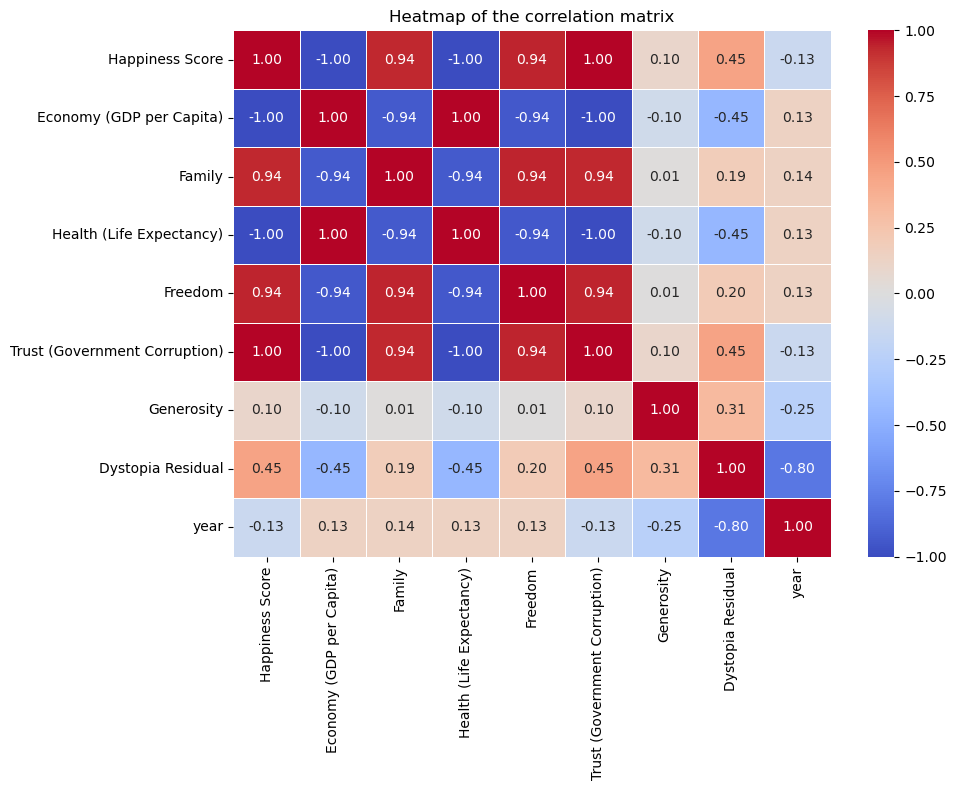

In [13]:
#correlation matrix
corr = df.corr(numeric_only=True)
num_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 8))
sns.heatmap(corr, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            linewidths=0.5, 
            linecolor='white',
            fmt=".2f")
plt.title("Heatmap of the correlation matrix")
plt.tight_layout()
plt.show()

<Figure size 1500x1300 with 0 Axes>

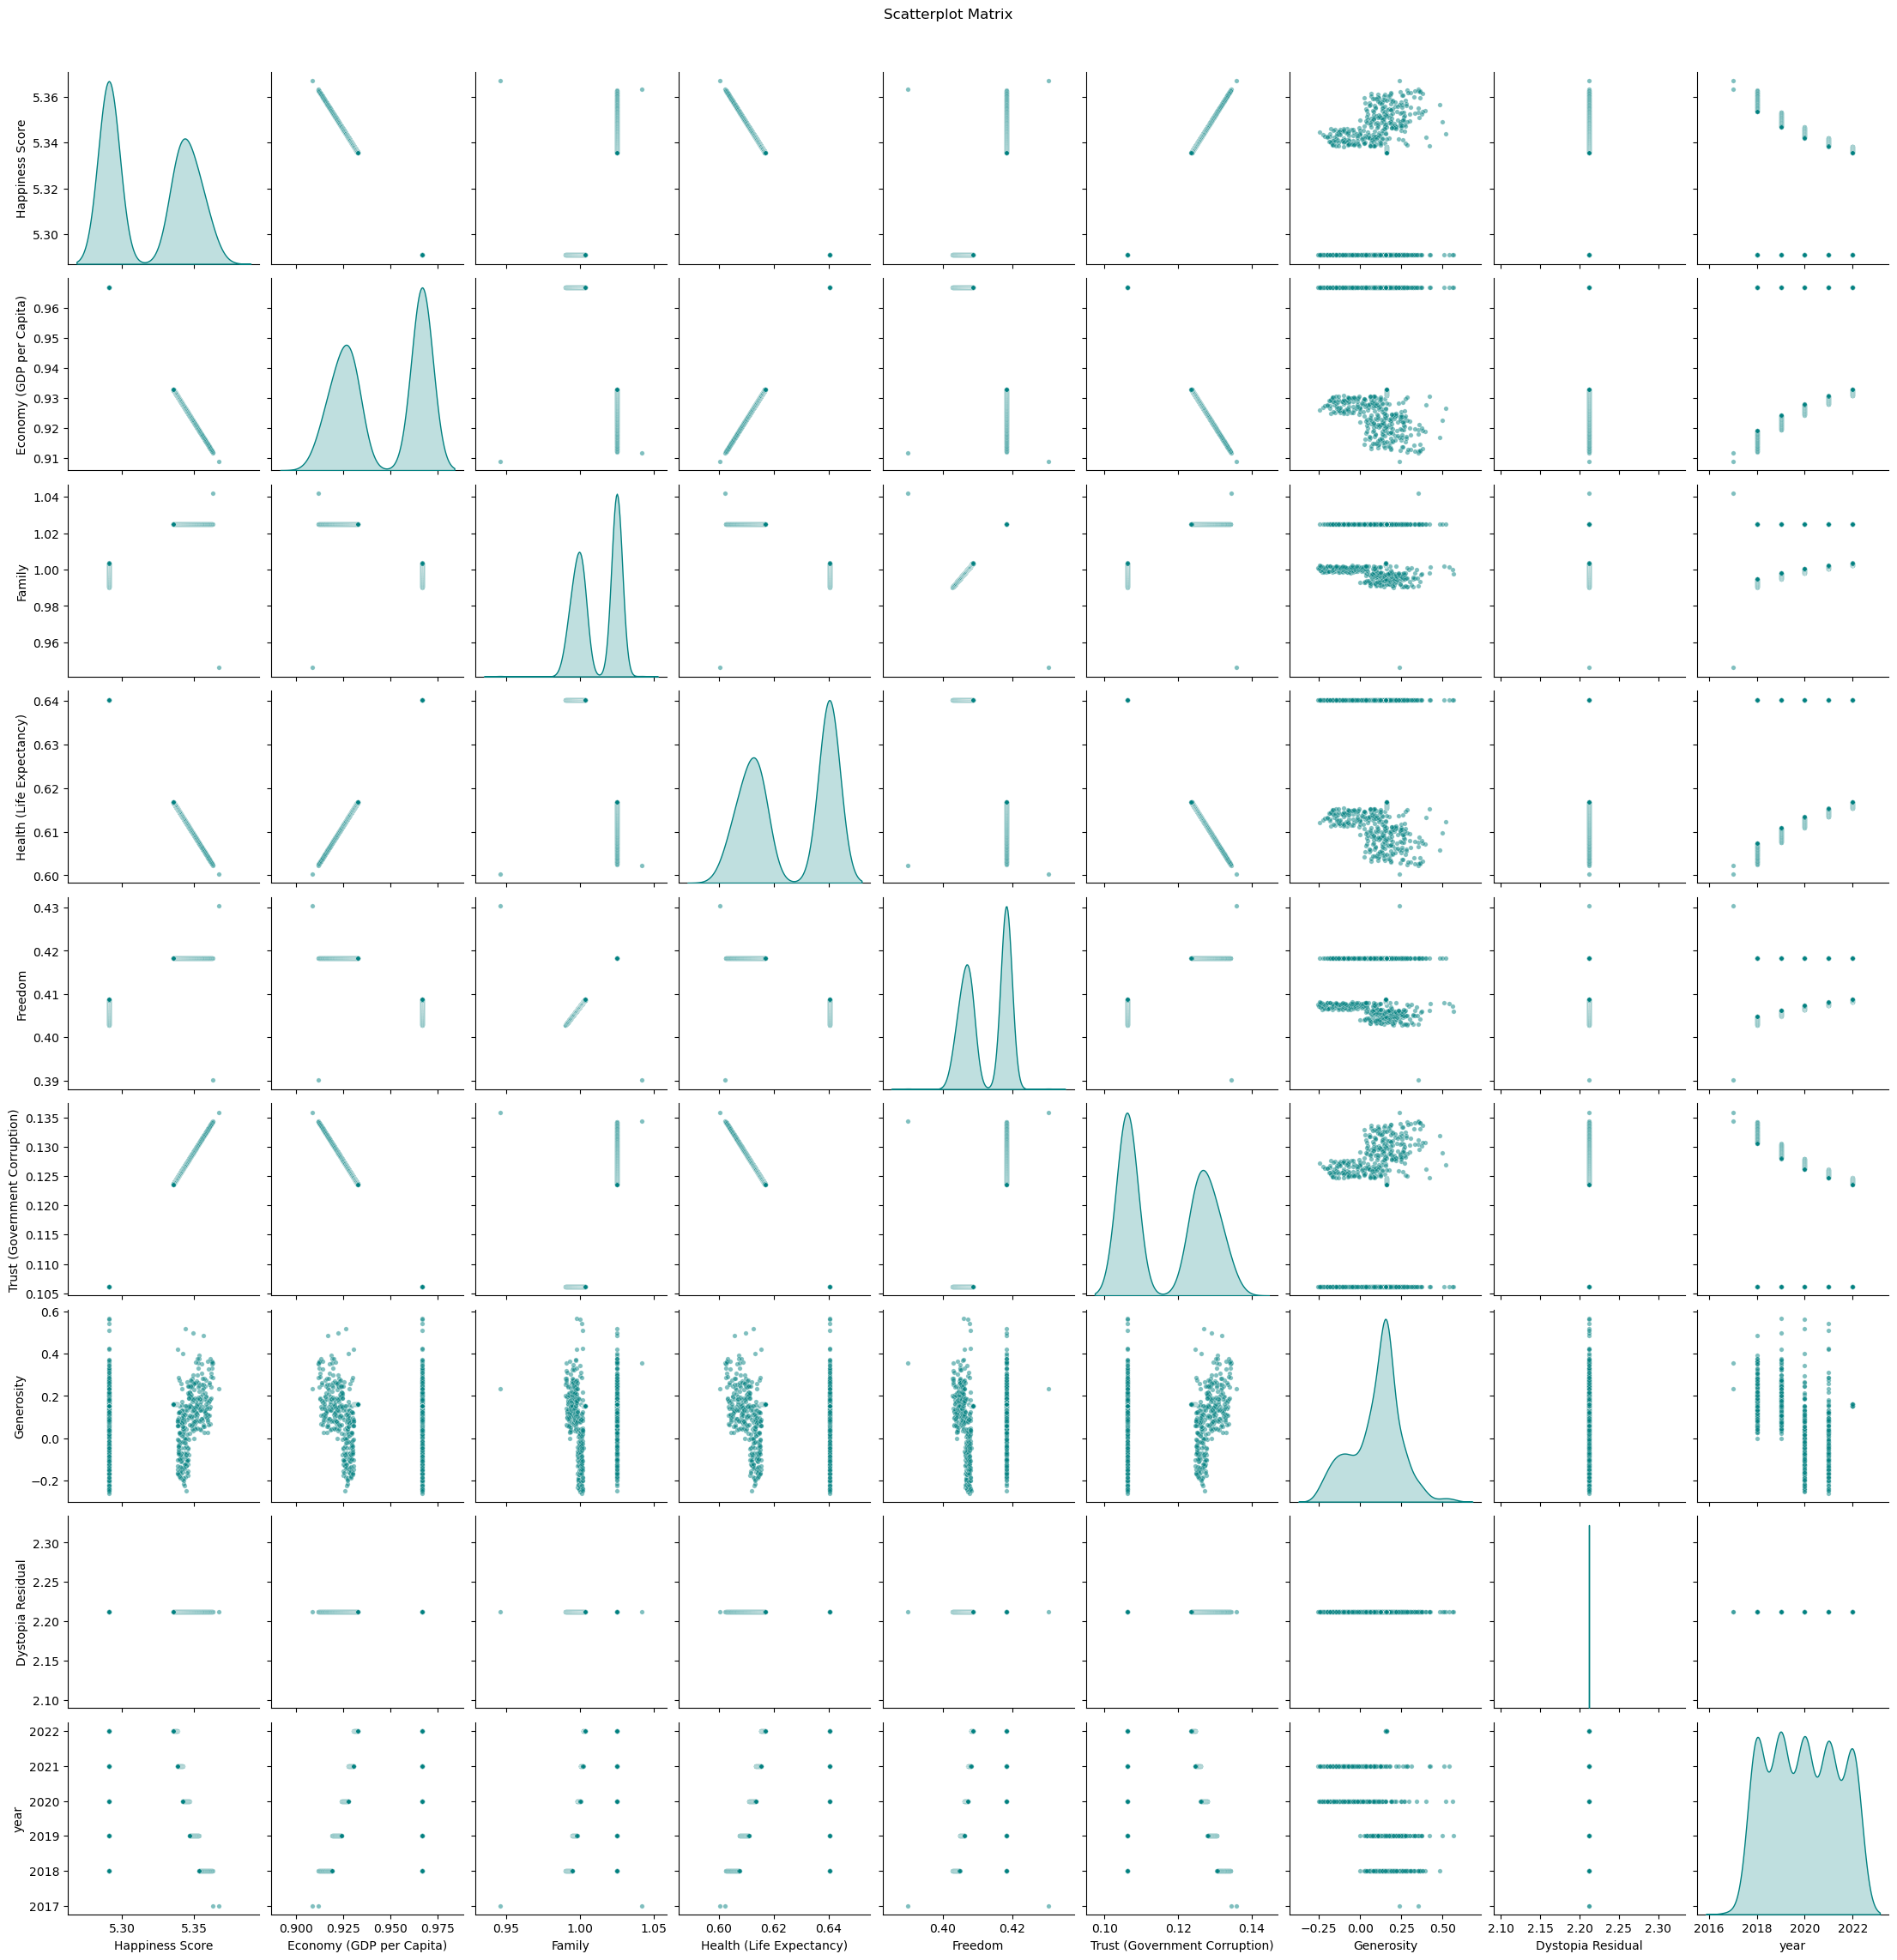

In [14]:
#scatterplot
plt.figure(figsize=(15, 13))
g = sns.pairplot(num_df, 
                 diag_kind='kde', 
                 plot_kws={'alpha': 0.5, 's': 15, 'color': 'teal'},
                 diag_kws={'color': 'teal', 'fill': True},
                 height=2.5)

g.figure.suptitle('Scatterplot Matrix', y=1.02)
plt.show()

**Combined Features**

In [15]:
df["Family_per_Health"] = df["Family"] / df["Health (Life Expectancy)"]
df["Economy_times_Freedom"] = df["Economy (GDP per Capita)"] * df["Freedom"]
df["Trust_per_Family"] = df["Trust (Government Corruption)"] / df["Family"]
df["Generosity_times_Health"] = df["Generosity"] * df["Health (Life Expectancy)"]
df["Economy_per_Trust"] = df["Economy (GDP per Capita)"] / (df["Trust (Government Corruption)"])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 758 entries, 421 to 1229
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        758 non-null    object 
 1   Happiness Score                758 non-null    float64
 2   Economy (GDP per Capita)       758 non-null    float64
 3   Family                         758 non-null    float64
 4   Health (Life Expectancy)       758 non-null    float64
 5   Freedom                        758 non-null    float64
 6   Trust (Government Corruption)  758 non-null    float64
 7   Generosity                     758 non-null    float64
 8   Dystopia Residual              758 non-null    float64
 9   year                           758 non-null    float64
 10  Family_per_Health              758 non-null    float64
 11  Economy_times_Freedom          758 non-null    float64
 12  Trust_per_Family               758 non-null    float

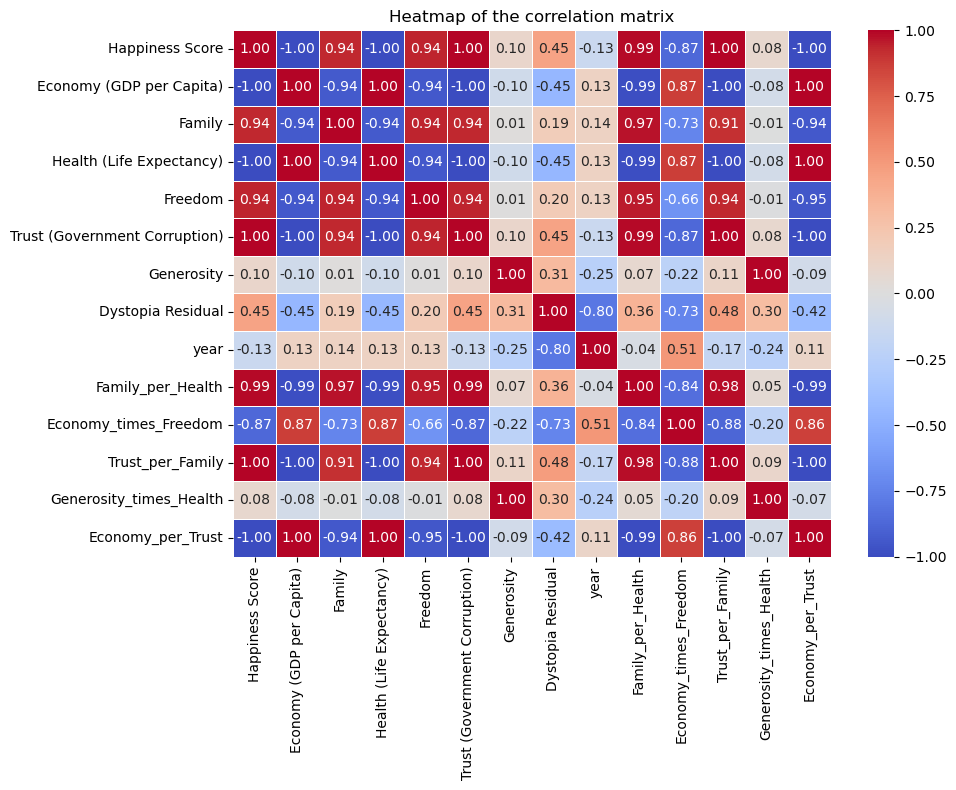

In [16]:
#correlation matrix
corr = df.corr(numeric_only=True)
num_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 8))
sns.heatmap(corr, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            linewidths=0.5, 
            linecolor='white',
            fmt=".2f")
plt.title("Heatmap of the correlation matrix")
plt.tight_layout()
plt.show()

In [17]:
#get dummies
df = pd.get_dummies(df, drop_first=True)

**MACHINE LEARNING**

In [18]:
X = df.drop(columns=["Happiness Score"])
y = df["Happiness Score"]

**Feature selection**
taken and adapted from an old exercise

In [19]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

selector_model = XGBRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    tree_method='hist', device='cpu', n_jobs=-1, random_state=42
)
selector_model.fit(X, y)
selection = SelectFromModel(selector_model, prefit=True, threshold='1.25*median')

X_selected = X.loc[:, selection.get_support()]

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

**Optuna: Choosing a Model**
Adapted from an old tutorial

In [20]:
#SDI validation for Optuna to monitor early stopping
X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

N_TRIALS = 50

#XGBoost Optimization
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 600, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.6),
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
        'alpha': trial.suggest_float('alpha', 1e-9, 15.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-9, 15.0, log=True),
        'n_jobs': -1, 'random_state': 42
    }
    
    model = XGBRegressor(**params)
    
    model.fit(
        X_opt_train, y_opt_train,
        eval_set=[(X_opt_val, y_opt_val)],
        verbose=False
    )
    
    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)

#CatBoost Optimization
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 700, 1300),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.8),
        'depth': trial.suggest_int('depth', 1, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'verbose': 0, 'allow_writing_files': False, 'random_state': 42
    }
    
    model = CatBoostRegressor(**params)
    
    model.fit(
        X_opt_train, y_opt_train,
        eval_set=[(X_opt_val, y_opt_val)],
        early_stopping_rounds=100
    )
    
    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=N_TRIALS)

#LightGBM Optimization
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 700, 1300),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.8),
        'num_leaves': trial.suggest_int('num_leaves', 25, 120),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.95),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 0.95),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10),
        'n_jobs': -1, 'verbose': -1, 'random_state': 42
    }
    
    model = LGBMRegressor(**params)
    
    callbacks = [
        early_stopping(stopping_rounds=100, verbose=False),
        log_evaluation(period=0)
    ]
    
    try:
        model.fit(
            X_opt_train, y_opt_train,
            eval_set=[(X_opt_val, y_opt_val)],
            eval_metric='rmse',
            callbacks=callbacks
        )
    except Exception as e:
        params['device'] = 'cpu'
        model = LGBMRegressor(**params)
        model.fit(
            X_opt_train, y_opt_train,
            eval_set=[(X_opt_val, y_opt_val)],
            eval_metric='rmse',
            callbacks=callbacks
        )

    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS)

#retrieve the best parameters
best_xgb_params = study_xgb.best_params
best_xgb_params.update({'n_estimators': 2000, 'tree_method': 'hist', 'device': 'cpu', 'n_jobs': -1, 'random_state': 42})
# Let's remove `early_stopping_rounds` from the parameters for the final fit
if 'early_stopping_rounds' in best_xgb_params: del best_xgb_params['early_stopping_rounds']

best_cat_params = study_cat.best_params
best_cat_params.update({'iterations': 2000, 'task_type': 'CPU', 'devices': '0', 'verbose': 0, 'random_state': 42})

best_lgbm_params = study_lgbm.best_params
best_lgbm_params.update({'n_estimators': 2000, 'device': 'cpu', 'n_jobs': -1, 'verbosity': -1, 'random_state': 42})

print("\nOptuna Complete. Best parameters found.")


[I 2026-03-27 16:01:57,542] A new study created in memory with name: no-name-1d0394bc-1425-4175-bf18-140fcf7a45ce
[I 2026-03-27 16:01:58,259] Trial 0 finished with value: 0.0016647712453796296 and parameters: {'n_estimators': 1195, 'learning_rate': 0.1066701813069147, 'max_depth': 19, 'subsample': 0.6957631761127712, 'colsample_bytree': 0.7408116316171243, 'alpha': 0.20467919811384835, 'lambda': 2.6496928585105677e-06}. Best is trial 0 with value: 0.0016647712453796296.
[I 2026-03-27 16:01:58,765] Trial 1 finished with value: 0.0001420938408316358 and parameters: {'n_estimators': 835, 'learning_rate': 0.21890247880281136, 'max_depth': 18, 'subsample': 0.6351976168900445, 'colsample_bytree': 0.8769382970288015, 'alpha': 3.0114586589048378e-05, 'lambda': 3.572369371645793e-06}. Best is trial 1 with value: 0.0001420938408316358.
[I 2026-03-27 16:01:59,395] Trial 2 finished with value: 7.247940619107904e-05 and parameters: {'n_estimators': 1072, 'learning_rate': 0.16172364638669445, 'max_d


Optuna Complete. Best parameters found.


**SMART MODEL SELECTORS**
taken and adapted from an old exercise

In [21]:
class SmartSoftModelSelector(BaseEstimator, RegressorMixin):
    def __init__(self, estimators, selector_model=None):
        self.estimators = estimators
        self.selector_model = selector_model if selector_model else XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.05,
            tree_method='hist', device='cpu', n_jobs=-1, random_state=42
        )
        self.model_names = [name for name, _ in estimators]
        
    def fit(self, X, y):
        self.fitted_estimators_ = []
        for name, model in self.estimators:
            model.fit(X, y)
            self.fitted_estimators_.append(model)
            
        #generation OOF Predictions
        errors = pd.DataFrame()
        
        for name, model in self.estimators:
            # cross_val_predict è essenziale per evitare leakage
            oof_preds = cross_val_predict(model, X, y, cv=5, n_jobs=1)
            errors[name] = np.abs(y - oof_preds)
            
        #creation Target for the selector
        y_best_model_idx = errors.idxmin(axis=1).apply(lambda x: self.model_names.index(x))
        
        #training for selector
        self.selector_model.fit(X, y_best_model_idx)
        return self

    def predict(self, X):
        #base prediction
        base_preds = np.column_stack([model.predict(X) for model in self.fitted_estimators_])
        #soft weights
        weights = self.selector_model.predict_proba(X)
        #Dynamic Weighted Average
        final_pred = np.sum(base_preds * weights, axis=1)
        return final_pred

#training the base models using Optuna's Best Params
estimators_list = [
    ('xgb', XGBRegressor(**best_xgb_params)),
    ('cat', CatBoostRegressor(**best_cat_params)),
    ('lgbm', LGBMRegressor(**best_lgbm_params)) 
]

#developing and train the MoE system
moe_model = SmartSoftModelSelector(estimators=estimators_list)
moe_model.fit(X_train, y_train)

SmartSoftModelSelector(estimators=[('xgb',
                                    XGBRegressor(alpha=1.1628239749650589e-05,
                                                 base_score=None, booster=None,
                                                 callbacks=None,
                                                 colsample_bylevel=None,
                                                 colsample_bynode=None,
                                                 colsample_bytree=0.6015114990750378,
                                                 device='cpu',
                                                 early_stopping_rounds=None,
                                                 enable_categorical=False,
                                                 eval_metric=None,
                                                 feature_types=None,
                                                 feature_weights=None,
                                                 gamma=None, grow_pol...
                                                    feature_weights=None,
                                                    gamma=None,
                                                    grow_policy=None,
                                                    importance_type=None,
                                                    interaction_constraints=None,
                                                    learning_rate=0.05,
                                                    max_bin=None,
                                                    max_cat_threshold=None,
                                                    max_cat_to_onehot=None,
                                                    max_delta_step=None,
                                                    max_depth=6,
                                                    max_leaves=None,
                                                    min_child_weight=None,
                                                    missing=nan,
                                                    monotone_constraints=None,
                                                    multi_strategy=None,
                                                    n_estimators=200, n_jobs=-1,
                                                    num_parallel_tree=None, ...))

**RESIDUE CORRECTOR**
adapted from an old exercise

In [22]:
class ResidualCorrectedMoE(BaseEstimator, RegressorMixin):
    def __init__(self, base_moe_model, corrector_model=None):
        self.base_moe_model = base_moe_model
        # Let's use a lightweight CatBoost as a corrector
        self.corrector_model = corrector_model if corrector_model else CatBoostRegressor(
            iterations=500,          
            depth=6, 
            learning_rate=0.03,
            l2_leaf_reg=5,           
            task_type='CPU', 
            devices='0',
            verbose=0,
            allow_writing_files=False,
            random_state=42
        )
        
    def fit(self, X, y):
        
        #generating OOF predictions to calculate the honest residuals
        print("Calcolo residui OOF (può richiedere tempo)...")
        oof_preds = cross_val_predict(self.base_moe_model, X, y, cv=5, n_jobs=1)
        
        #Error calculation
        residuals = y - oof_preds
        
        print(f"      Media Residui: {residuals.mean():.4f}")
        print(f"      Deviaz. Std Residui: {residuals.std():.4f}")
        
        #corrector training
        print("Training del Correttore...")
        self.corrector_model.fit(X, residuals)
        return self

    def predict(self, X):
        base_pred = self.base_moe_model.predict(X)
        correction = self.corrector_model.predict(X)
        return base_pred + (1.0 * correction)

#final construction
final_system = ResidualCorrectedMoE(base_moe_model=moe_model)
final_system.fit(X_train, y_train)

#valutation
y_pred_corrected = final_system.predict(X_test)

final_rmse_corr = np.sqrt(mean_squared_error(y_test, y_pred_corrected))
final_r2_corr = r2_score(y_test, y_pred_corrected)

print(f"\n==========================================")
print(f" OPTIMIZED FINAL RESULTS")
print(f"==========================================")
print(f" RMSE: {final_rmse_corr:.5f}")
print(f" R^2 : {final_r2_corr:.5f}")
print(f"==========================================")

Calcolo residui OOF (può richiedere tempo)...
      Media Residui: 0.0001
      Deviaz. Std Residui: 0.0014
Training del Correttore...

 OPTIMIZED FINAL RESULTS
 RMSE: 0.00018
 R^2 : 0.99996


**Grafico correttore e modelli ottimizzati**

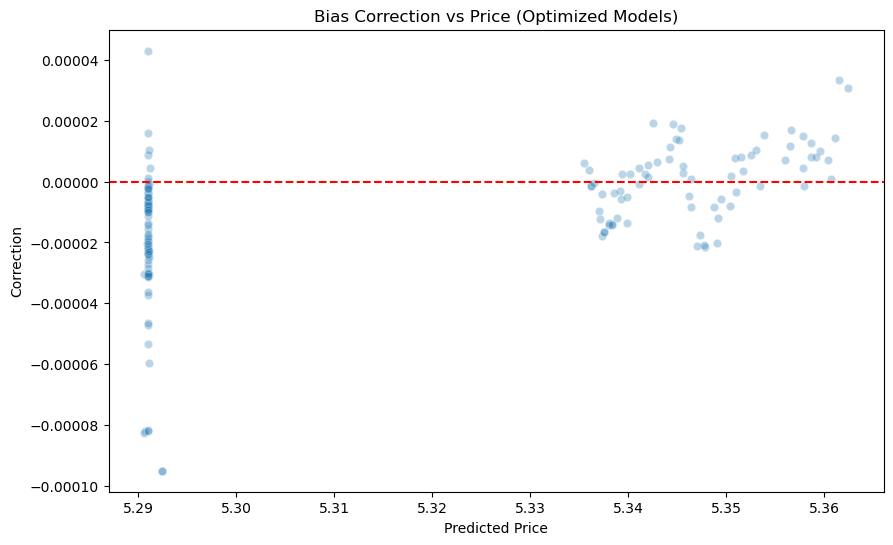

In [23]:
corrections_test = final_system.corrector_model.predict(X_test)
base_preds_test = final_system.base_moe_model.predict(X_test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=base_preds_test, y=corrections_test, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title("Bias Correction vs Price (Optimized Models)")
plt.xlabel("Predicted Price")
plt.ylabel("Correction")
plt.show()

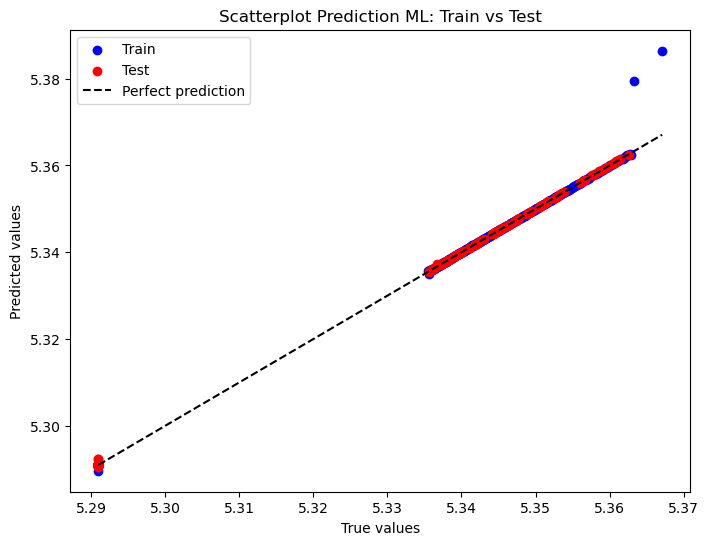

In [24]:
y_train_pred = final_system.predict(X_train)
y_test_pred = final_system.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(y_train, y_train_pred, color='blue', label='Train')

plt.scatter(y_test, y_test_pred, color='red', label='Test')

max_val = max(max(y_train), max(y_test))
min_val = min(min(y_train), min(y_test))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect prediction')

plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.title('Scatterplot Prediction ML: Train vs Test')
plt.legend()
plt.show()
